In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


In [2]:
df = pd.read_csv("youtube_ad_revenue_dataset.csv")

In [3]:
df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [4]:
df.shape

(122400, 12)

In [5]:
df.columns

Index(['video_id', 'date', 'views', 'likes', 'comments', 'watch_time_minutes',
       'video_length_minutes', 'subscribers', 'category', 'device', 'country',
       'ad_revenue_usd'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  object 
 1   date                  122400 non-null  object 
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  object 
 9   device                122400 non-null  object 
 10  country               122400 non-null  object 
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.2+ MB


In [7]:
df.isnull().sum()

video_id                   0
date                       0
views                      0
likes                   6117
comments                6112
watch_time_minutes      6105
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

In [8]:
df.dtypes

video_id                 object
date                     object
views                     int64
likes                   float64
comments                float64
watch_time_minutes      float64
video_length_minutes    float64
subscribers               int64
category                 object
device                   object
country                  object
ad_revenue_usd          float64
dtype: object

In [9]:
df.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,122400.000000,116283.000000,116288.000000,116295.000000,122400.000000,122400.000000,122400.000000
mean,9999.856283,1099.633618,274.396636,37543.827721,16.014165,502191.719902,252.727210
std,99.881260,519.424089,129.741739,12987.724246,8.083790,288397.470103,61.957052
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,9933.000000,650.000000,162.000000,26366.320569,9.004695,252507.500000,199.902018
50%,10000.000000,1103.000000,274.000000,37531.990337,16.005906,503465.500000,252.749699
75%,10067.000000,1547.000000,387.000000,48777.782090,23.021260,752192.000000,305.597518
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254


## Preprocessing: remove duplicates , Handle missing values

### 1. Remove duplicates

In [10]:
# check duplicates

df.duplicated().sum()

np.int64(2400)

In [11]:
  # Remove Duplicates

before = len(df)
df.drop_duplicates(inplace=True)
print("Duplicates Removed:", before - len(df))

Duplicates Removed: 2400


### 2. Handle missing values

In [12]:
#  Handle missing values 

# likes & comments → 0
df[['likes', 'comments']] = df[['likes', 'comments']].fillna(0)

# watch_time_minutes → median
df['watch_time_minutes'] = df['watch_time_minutes'].fillna(df['watch_time_minutes'].median())

In [13]:
df.isnull().sum()

video_id                0
date                    0
views                   0
likes                   0
comments                0
watch_time_minutes      0
video_length_minutes    0
subscribers             0
category                0
device                  0
country                 0
ad_revenue_usd          0
dtype: int64

## EDA (Exploratory Data Analysis): Identify trends, correlations, and outliers.

### 1 . identify tends (date, views,country and ad revenue)

In [14]:
# check date columns

df['date'].head()

0    2024-09-24 10:50:40.993199
1    2024-09-22 10:50:40.993199
2    2024-11-21 10:50:40.993199
3    2025-01-28 10:50:40.993199
4    2025-04-28 10:50:40.993199
Name: date, dtype: object

In [15]:
# 1.1 Date conversion & Feature derivation

df['Date'] = pd.to_datetime(df.get('date', df.get('Date')), errors='coerce')  # Convert date column to datetime format

df['Year'] = df['Date'].dt.year       # Extract year from date

df['Quarter'] = 'Q' + df['Date'].dt.quarter.astype(str)     # Extract quarter from date

df['Date'] = df['Date'].dt.date  # Time-a removed 

#  Verify
df[['Date', 'Year', 'Quarter']].head()

,Date,Year,Quarter
0,2024-09-24,2024,Q3
1,2024-09-22,2024,Q3
2,2024-11-21,2024,Q4
3,2025-01-28,2025,Q1
4,2025-04-28,2025,Q2


In [16]:
# 1.2 Time-based Trends (Views & Revenue)

# Group data by date and calculate total views and ad revenue
trend_df = df.groupby('Date')[['views', 'ad_revenue_usd']].sum().reset_index()

trend_df.head() 
                 # Trend identified: Shows how views and ad revenue change over time.

,Date,views,ad_revenue_usd
0,2024-06-09,3371136,86792.136584
1,2024-06-10,3189709,80735.290329
2,2024-06-11,3390373,85152.787848
3,2024-06-12,3260005,82808.351046
4,2024-06-13,3228308,82065.660282


In [17]:
# 1.3  Category Trend

# Group data by category and calculate average views and ad revenue
category_trend = df.groupby('category')[['views', 'ad_revenue_usd']].mean().reset_index()

category_trend
                     # Trend identified: Which content category performs better on average.
                     # High revenue vs low revenue categories

,category,views,ad_revenue_usd
0,Education,9999.914078,252.564162
1,Entertainment,10000.106367,252.397546
2,Gaming,9999.773706,253.426887
3,Lifestyle,9999.808137,251.936934
4,Music,10000.379915,252.477374
5,Tech,9999.009986,253.458882


In [18]:
# 1.4 Device- Trend

# Group data by device type and calculate total views
device_trend = df.groupby('device')['views'].sum().reset_index()

device_trend
           # which device has the highest views.

,device,views
0,Desktop,299857961
1,Mobile,299895167
2,TV,300838647
3,Tablet,299388105


In [19]:
# 1.5 Country  Revenue Trends

# Group data by country and calculate total ad revenue
country_trend = (df.groupby('country')['ad_revenue_usd'].sum().reset_index().sort_values('ad_revenue_usd', ascending=False))

country_trend
             # Which country generates the highest revenue

,country,ad_revenue_usd
1,CA,5.106761e+06
2,DE,5.095423e+06
3,IN,5.089260e+06
0,AU,5.026759e+06
4,UK,5.024095e+06
5,US,4.983066e+06


## 2 . Correlation

### Correlation  ( Heatmap )


In [20]:
# Numeric columns only
df_numeric = df.select_dtypes(include='number')

# Correlation matrix
corr = df_numeric.corr()


print(corr['ad_revenue_usd'].sort_values(ascending=False))

ad_revenue_usd          1.000000
watch_time_minutes      0.964052
likes                   0.128878
views                   0.037942
comments                0.028335
subscribers             0.005065
Year                    0.001053
video_length_minutes    0.000364
Name: ad_revenue_usd, dtype: float64


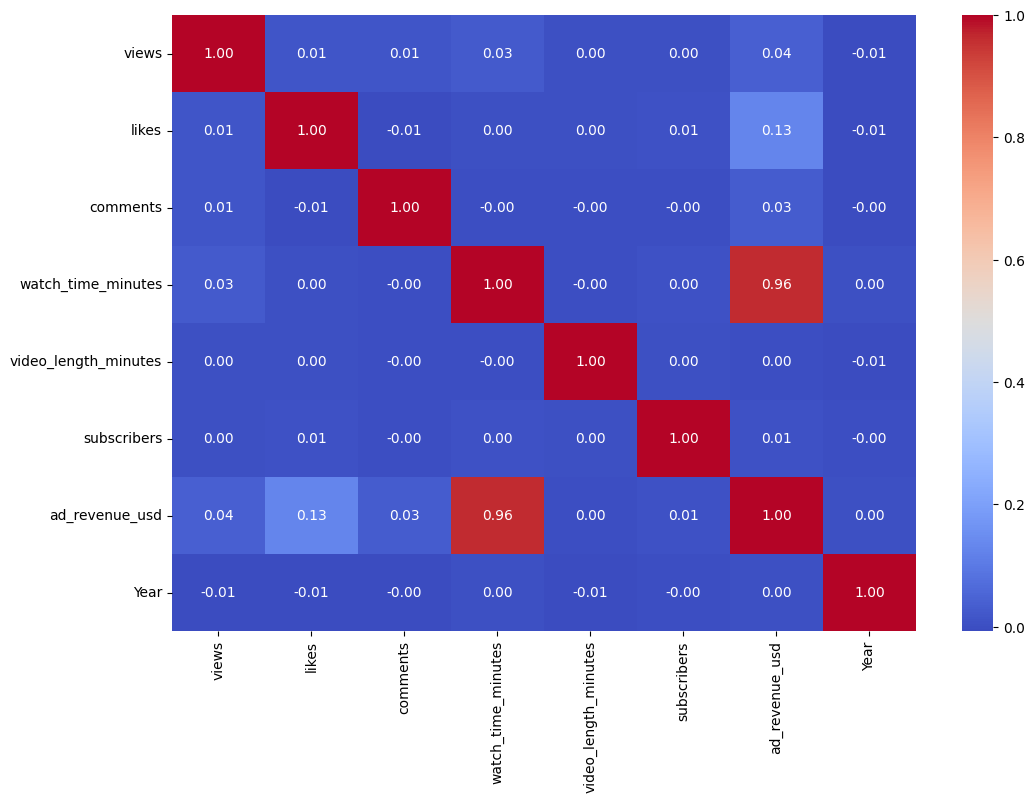

In [21]:
# correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

##  3 . Outliers :  (Statistical , Visual )


### 3 . 1 Statistical  
using Method Z-Score.

In [22]:
num_df = df.select_dtypes(include=np.number)

#  Z-Score Method

threshold = 3

z_scores = np.abs(stats.zscore(num_df)) 


print("Size before check outliers:", df.shape)

outlier_rows = (z_scores > threshold).any(axis=1)

df_clean = df[~outlier_rows]

outlier_rows_df = df[outlier_rows]

print("Size after removing check outliers:", df_clean.shape)


Size before check outliers: (120000, 15)
Size after removing check outliers: (119684, 15)


In [23]:
outlier_rows_df.shape

(316, 15)

In [24]:

print("Deleted (outlier) rows:")
outlier_rows_df.head()

Deleted (outlier) rows:


,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,Date,Year,Quarter
502,vid_3071,2024-12-14 10:50:40.993199,10360,1466.0,361.0,52927.517291,7.352242,27886,Gaming,Desktop,IN,334.909633,2024-12-14,2024,Q4
627,vid_74,2024-08-30 10:50:40.993199,10304,2000.0,388.0,28831.030698,29.861329,981940,Music,TV,IN,230.656210,2024-08-30,2024,Q3
772,vid_4945,2024-11-21 10:50:40.993199,9669,1632.0,398.0,37522.221205,7.617316,383868,Entertainment,Mobile,US,159.707096,2024-11-21,2024,Q4
953,vid_1073,2025-02-08 10:50:40.993199,9698,1475.0,394.0,31287.196729,4.814729,982076,Lifestyle,Tablet,CA,230.158158,2025-02-08,2025,Q1
1229,vid_2916,2024-11-09 10:50:40.993199,9674,704.0,71.0,49249.560591,12.853055,271106,Music,TV,IN,295.914351,2024-11-09,2024,Q4


## 3 . 2  Visual Outlier 


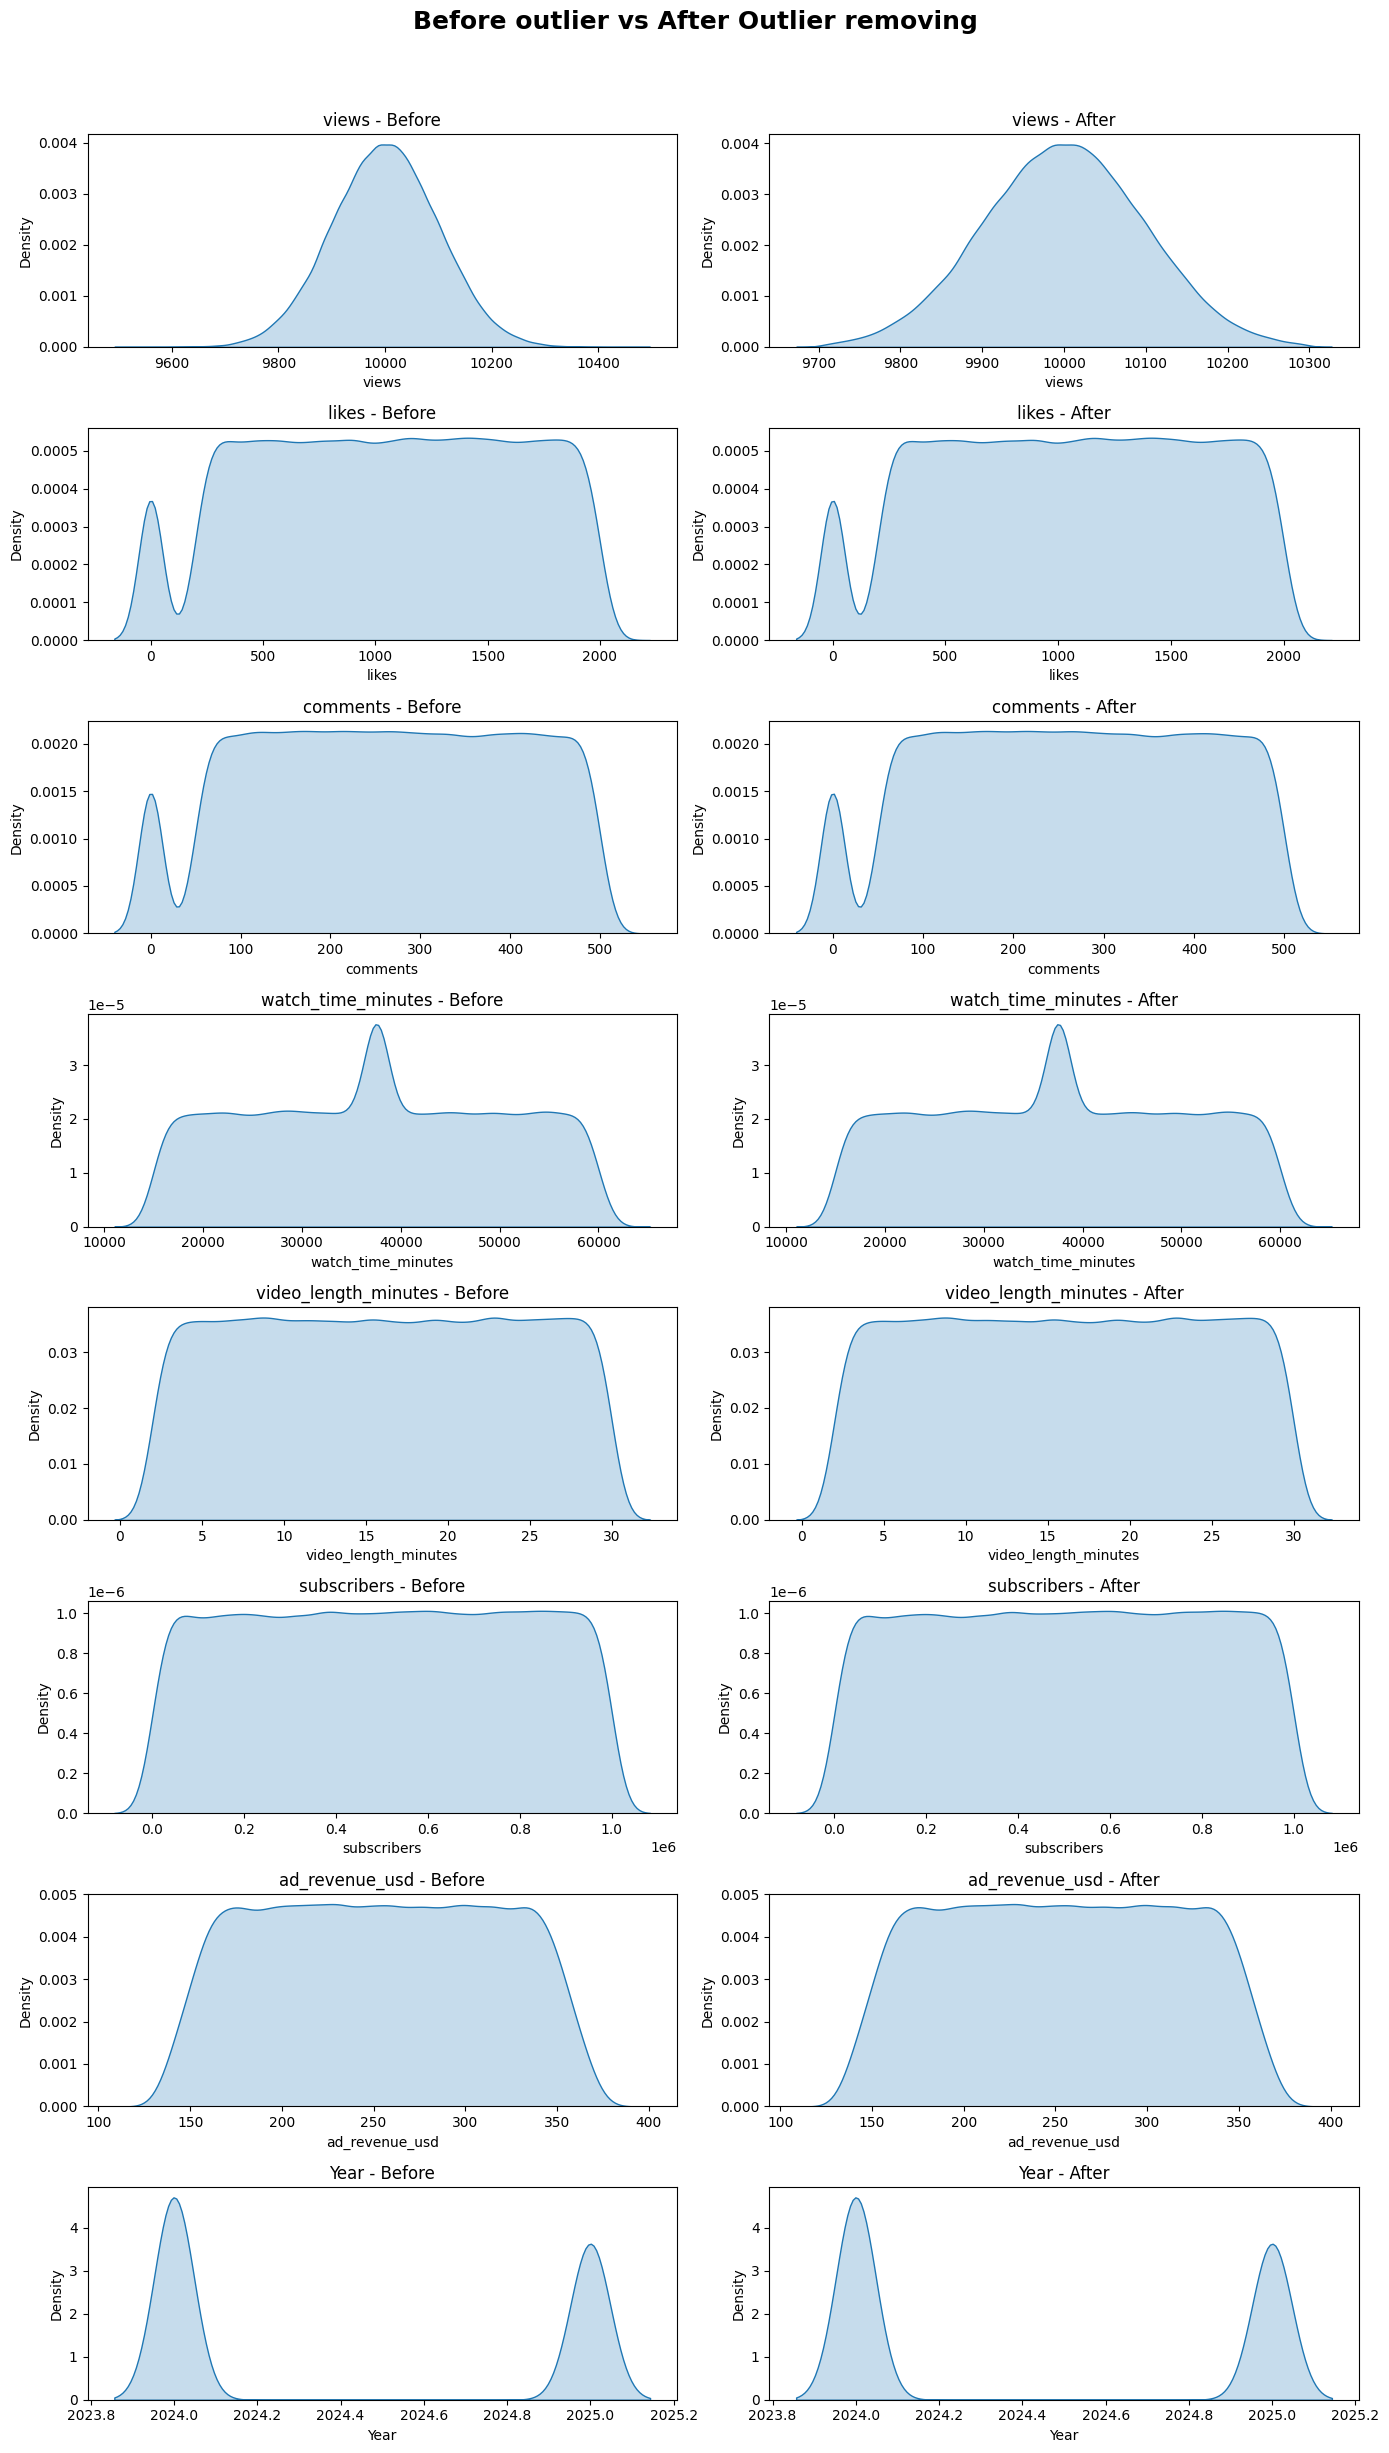

In [25]:
numeric_features = df.select_dtypes(include='number').columns

rows = len(numeric_features)

fig, axes = plt.subplots(rows, 2, figsize=(14, 3*rows))

fig.suptitle("Before outlier vs After Outlier removing",fontsize=18,fontweight="bold",y=1.02)

for i, col in enumerate(numeric_features):

    #  Before
    sns.kdeplot(x=df[col], ax=axes[i, 0], fill=True)
    axes[i, 0].set_title(f"{col} - Before")
    axes[i, 0].set_xlabel(col)

    #  After
    sns.kdeplot(x=df_clean[col], ax=axes[i, 1], fill=True)
    axes[i, 1].set_title(f"{col} - After")
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()


## Skewness Value

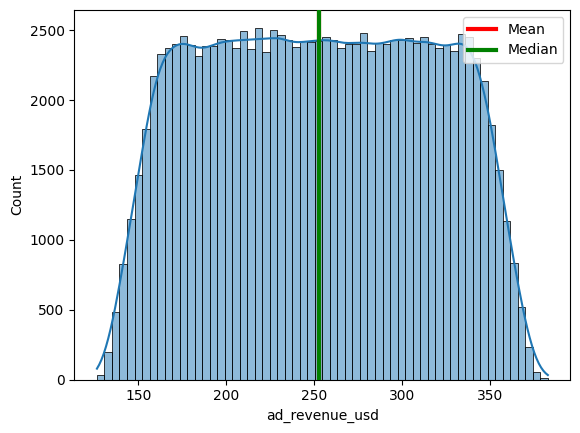

Skewness Value: 0.0009478946949712725
Skewness: 0.00 ( Normal Distribution)


In [26]:

skew_value = df['ad_revenue_usd'].skew()

# 1. Plot Graph (lw=3 and zorder=5 ensures lines are visible)
sns.histplot(df['ad_revenue_usd'], kde=True)
plt.axvline(df['ad_revenue_usd'].mean(), color='r', lw=3, label='Mean', zorder=5)
plt.axvline(df['ad_revenue_usd'].median(), color='g', lw=3, label='Median', zorder=5)
plt.legend(); plt.show()


# Print the value
print(f"Skewness Value: {skew_value}")

res = ("Positive" if skew_value > 0.5 else "Negative" if skew_value < -0.5 else " Normal Distribution")

print(f"Skewness: {skew_value:.2f} ({res})")

## Encode categorical variables.

In [27]:
# One-Hot Encode categorical columns and get numeric output
df = pd.get_dummies(df,columns=['category', 'device', 'country'],drop_first=True,dtype=int)
df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd,Date,...,category_Music,category_Tech,device_Mobile,device_TV,device_Tablet,country_CA,country_DE,country_IN,country_UK,country_US
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,203.178237,2024-09-24,...,0,0,0,1,0,0,0,1,0,0
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,140.880508,2024-09-22,...,0,0,0,0,1,1,0,0,0,0
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,360.134008,2024-11-21,...,0,0,0,1,0,1,0,0,0,0
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,224.638261,2025-01-28,...,0,0,1,0,0,0,0,0,1,0
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,165.514388,2025-04-28,...,0,0,1,0,0,1,0,0,0,0


In [28]:
# remove date columns 
columns_to_remove = ['date']
df.drop(columns=columns_to_remove)
df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd,Date,...,category_Music,category_Tech,device_Mobile,device_TV,device_Tablet,country_CA,country_DE,country_IN,country_UK,country_US
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,203.178237,2024-09-24,...,0,0,0,1,0,0,0,1,0,0
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,140.880508,2024-09-22,...,0,0,0,0,1,1,0,0,0,0
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,360.134008,2024-11-21,...,0,0,0,1,0,1,0,0,0,0
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,224.638261,2025-01-28,...,0,0,1,0,0,0,0,0,1,0
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,165.514388,2025-04-28,...,0,0,1,0,0,1,0,0,0,0


### Feature Engineering: Create new features ( engagement rate = (likes + comments) / views).

In [29]:
# 3. Feature Engineering

df['engagement_rate'] = (df['likes'] + df['comments']) / (df['views'] + 1)

In [30]:
df.columns

Index(['video_id', 'date', 'views', 'likes', 'comments', 'watch_time_minutes',
       'video_length_minutes', 'subscribers', 'ad_revenue_usd', 'Date', 'Year',
       'Quarter', 'category_Entertainment', 'category_Gaming',
       'category_Lifestyle', 'category_Music', 'category_Tech',
       'device_Mobile', 'device_TV', 'device_Tablet', 'country_CA',
       'country_DE', 'country_IN', 'country_UK', 'country_US',
       'engagement_rate'],
      dtype='object')

In [31]:
df.shape

(120000, 26)

### check : columns

In [32]:
df[['engagement_rate']].head()

,engagement_rate
0,0.155077
1,0.098622
2,0.214498
3,0.142800
4,0.236097


In [33]:
df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd,Date,...,category_Tech,device_Mobile,device_TV,device_Tablet,country_CA,country_DE,country_IN,country_UK,country_US,engagement_rate
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,203.178237,2024-09-24,...,0,0,1,0,0,0,1,0,0,0.155077
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,140.880508,2024-09-22,...,0,0,0,1,1,0,0,0,0,0.098622
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,360.134008,2024-11-21,...,0,0,1,0,1,0,0,0,0,0.214498
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,224.638261,2025-01-28,...,0,1,0,0,0,0,0,1,0,0.142800
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,165.514388,2025-04-28,...,0,1,0,0,1,0,0,0,0,0.236097


In [34]:
df.shape

(120000, 26)

## Model Building: Experiment with 5 different regression models to predict ad_revenue_usd, and compare their performance to identify the most effective model.

## Train_Test_split

In [35]:
from sklearn.model_selection import train_test_split

# Select only numerical columns from the dataframe
X = df.select_dtypes(include=['number']).drop('ad_revenue_usd', axis=1)

# Target variable
y = df['ad_revenue_usd']

# Split the dataset into training and testing data

# test_size=0.2 20% data for testing, 80% for training

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
                                                                        # random_state=42  ensures same split every time

##  Scaling

In [36]:
from sklearn.preprocessing import StandardScaler

#  Scaling
scaler = StandardScaler()

# Train data scale
X_train_scaled = scaler.fit_transform(X_train)

# Test data scale
X_test_scaled = scaler.transform(X_test)



In [37]:
X_train. shape, X_test.shape, y_train.shape, y_test.shape

((96000, 21), (24000, 21), (96000,), (24000,))

In [38]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
                                                   
#  Models to compare

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "RandomForest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)}

# Model training , Predict , Evaluate

for name, model in models.items():

    model.fit(X_train, y_train) # Model training  
    
    preds = model.predict(X_test) # Predict the data

    r2 = r2_score(y_test, preds) # R²

    rmse = np.sqrt(mean_squared_error(y_test, preds)) # Root Mean Squared Error (RMSE)

    mae = mean_absolute_error(y_test, preds) # Mean Absolute Error (MAE)

       #  Evaluate

    print(f"{name} → R2: {r2:.3f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}")


Linear → R2: 0.949, RMSE: 14.02, MAE: 4.79
Ridge → R2: 0.949, RMSE: 14.02, MAE: 4.79
Lasso → R2: 0.949, RMSE: 14.02, MAE: 4.79
RandomForest → R2: 0.950, RMSE: 13.89, MAE: 3.54
GradientBoosting → R2: 0.952, RMSE: 13.53, MAE: 3.68


## Model Evaluation 

In [39]:
#  Models to compare
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "RandomForest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)}



results = []          # Store all model evaluation metrics


# Model training , Predict ,  results comparison ,  Evaluate

for name, model in models.items():

    model.fit(X_train, y_train) # Model training

    preds = model.predict(X_test)  # Predict the data
    
    r2 = r2_score(y_test, preds)  # R²

    rmse = np.sqrt(mean_squared_error(y_test, preds))  # Root Mean Squared Error (RMSE)

    mae = mean_absolute_error(y_test, preds)   # Mean Absolute Error (MAE)


    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100 #  MAPE :  percentage error


    
    # Store results for comparison
    
    results.append({"Model": name, "R2": r2, "RMSE": rmse, "MAE": mae, "MAPE%": mape})


       #  Evaluate

    print(f"{name:16} | R2: {r2:.3f} | RMSE: {rmse:.2f} | MAE: {mae:.2f} | MAPE: {mape:.2f}%")

Linear           | R2: 0.949 | RMSE: 14.02 | MAE: 4.79 | MAPE: 2.06%
Ridge            | R2: 0.949 | RMSE: 14.02 | MAE: 4.79 | MAPE: 2.06%
Lasso            | R2: 0.949 | RMSE: 14.02 | MAE: 4.79 | MAPE: 2.06%
RandomForest     | R2: 0.950 | RMSE: 13.89 | MAE: 3.54 | MAPE: 1.52%
GradientBoosting | R2: 0.952 | RMSE: 13.53 | MAE: 3.68 | MAPE: 1.59%


In [40]:
# Create comparison table

results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False)
results_df

,Model,R2,RMSE,MAE,MAPE%
4,GradientBoosting,0.952219,13.530469,3.681314,1.585790
3,RandomForest,0.949649,13.889509,3.540498,1.519411
2,Lasso,0.948728,14.015968,4.785475,2.055786
0,Linear,0.948716,14.017570,4.787951,2.056719
1,Ridge,0.948716,14.017660,4.788137,2.056797


# Check : Final Model

In [41]:
results_df = pd.DataFrame(results)

best_model_name = results_df.sort_values(by=['R2', 'RMSE'],ascending=[False, True]).iloc[0]['Model']

best_model = models[best_model_name]

print("Final Model:", best_model_name)


Final Model: GradientBoosting


#  Pickle

In [42]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("model saved successfully ")


model saved successfully 
